# PCHN63112 Workshop: Introduction to Mixed-effects 
In the associated lesson, we introduced the mixed-effects framework as a more general approach to dealing with dependence in our data. This initial introduction kept the model quite simple and our exposition of the theory and logic was somewhat limited. However, you should have *some* sense of what these models are doing, even if it does not feel completely clear at present. The materials for this week will dig into this much more to try and expose the full framework to you. For now, our aim is just to play around with some different model specifications and examine the effects on the assumed covariance structure and inference. In this workshop, we will present some further examples of mixed-effects models, as applied to the datasets used for discussing GLS last week. We will also examine assumptions testing using a visual approach similar to those used for `lm()` and `gls()` last week. The aim is not to be fully familiar at this point, rather it is to gain exposure to this approach to start building your intuition.

## Multiple Within-subject Factors
We will start with an example of a mixed-effects model applied to multiple within-subject factors. As with last week, we will use the `weightloss` dataset included with `datarium`. Below is the code for loading the data, restructuring it into long-format and then printing the values associated with the first subject.

In [1]:
library('datarium')
library('reshape2')

data('weightloss')

# repeats and number of subjects
t <- 12 # 2 * 2 * 3
n <- 12

# reshape wide -> long
weightloss.long <- melt(weightloss,                         # wide data frame
                        id.vars=c('id','diet','exercises'), # what stays fixed?
                        variable.name="time",               # name for the new predictor
                        value.name="weight")                # name for the new outcome

weightloss.long           <- weightloss.long[order(weightloss.long$id),] # order by ID
rownames(weightloss.long) <- seq(1,n*t)                                  # fix row names

weightloss.long$id        <- as.factor(weightloss.long$id)               # id as factor
weightloss.long$diet      <- as.factor(weightloss.long$diet)             # diet as factor
weightloss.long$exercises <- as.factor(weightloss.long$exercises)        # exercises as factor
weightloss.long$time      <- as.factor(weightloss.long$time)             # time as factor

weightloss.long[weightloss.long$id == '1',]

   id diet exercises time weight
1   1   no        no   t1  10.43
2   1   no       yes   t1  11.12
3   1  yes        no   t1  10.20
4   1  yes       yes   t1  10.43
5   1   no        no   t2  13.21
6   1   no       yes   t2  12.51
7   1  yes        no   t2  12.51
8   1  yes       yes   t2  12.51
9   1   no        no   t3  11.59
10  1   no       yes   t3  15.76
11  1  yes        no   t3  14.60
12  1  yes       yes   t3  14.37

### Basic Random-effects Structure
The most basic model we can fit includes a random intercept per-subject. We will discuss the process of building these models in more detail next week, so do not worry too much about the theory behind this. The aim here is just to explore more examples of basic mixed-effects models. 

We can specify this using the syntax below, where we use `random= ~ 1|id` for the random-effects.

In [2]:
library(nlme)
weightloss.lme.0 <- lme(weight ~ diet*exercises*time, random= ~ 1|id, data=weightloss.long)
summary(weightloss.lme.0)

Linear mixed-effects model fit by REML
  Data: weightloss.long 
       AIC      BIC    logLik
  469.9397 510.2989 -220.9699

Random effects:
 Formula: ~1 | id
        (Intercept) Residual
StdDev:    0.317161 1.120828

Fixed effects:  weight ~ diet * exercises * time 
                                Value Std.Error  DF  t-value p-value
(Intercept)                 10.909167 0.3362595 121 32.44270  0.0000
dietyes                      0.833333 0.4575760 121  1.82119  0.0710
exercisesyes                -0.115000 0.4575760 121 -0.25132  0.8020
timet2                       0.656667 0.4575760 121  1.43510  0.1538
timet3                       0.540833 0.4575760 121  1.18195  0.2395
dietyes:exercisesyes        -0.234167 0.6471102 121 -0.36187  0.7181
dietyes:timet2               0.016667 0.6471102 121  0.02576  0.9795
dietyes:timet3               1.503333 0.6471102 121  2.32315  0.0218
exercisesyes:timet2          1.970000 0.6471102 121  3.04430  0.0029
exercisesyes:timet3          5.482500 0.64

Notice that there are only *two* variances in this model, as indicated by `StdDev` under the `Random effects:` section. This indicates already that this model is assuming *compound symmetry* and so, at present, is not much improvement over a repeated measures ANOVA. 

Putting this to one side, we can generate an ANOVA table as usual

In [3]:
library(car)
Anova(weightloss.lme.0)

Loading required package: carData


Analysis of Deviance Table (Type II tests)

Response: weight
                       Chisq Df Pr(>Chisq)    
diet                  4.0687  1    0.04368 *  
exercises            56.6472  1  5.215e-14 ***
time                168.2687  2  < 2.2e-16 ***
diet:exercises       26.5860  1  2.521e-07 ***
diet:time             1.9260  2    0.38174    
exercises:time       53.6780  2  2.208e-12 ***
diet:exercises:time  24.4971  2  4.792e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

which is suggestive of a 3-way interaction between `diet`, `exercises` and `time`. We can plot this using `effects`

lattice theme set by effectsTheme()
See ?effectsTheme for details.


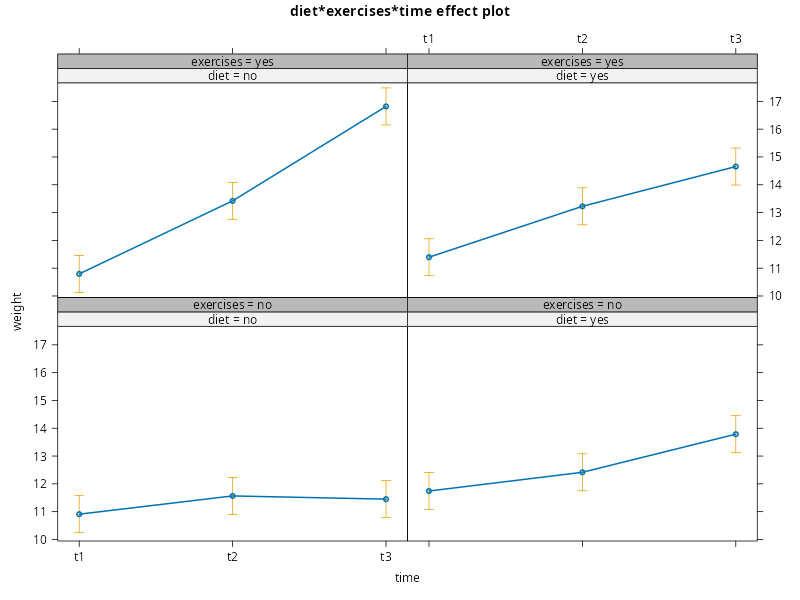

In [4]:
library(effects)
plot(effect('diet:exercises:time', weightloss.lme.0))

which is strongly suggestive of a combined effect of both `diet` and `exercises` on the amount of weight loss over time. 

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 1</b> How would you break this interaction down using <code>emmeans</code>?
</div>

### Multilevel Conceptualisation
To connect with the materials from the lesson, the multilevel conceptualisation of this model is as follows

$$
\begin{alignat*}{1}
\text{Level 1}\\
    y_{ijkt} &= \mu_{i} + \alpha_{j} + \beta_{k} + \gamma_{t} + (\alpha\beta)_{jk} + (\alpha\gamma)_{jt} + (\beta\gamma)_{kt} + (\alpha\beta\gamma)_{jkt} + \eta_{ijkt} \\
    \quad \\
\text{Level 2} \\
    \mu_{i} &= \mu + \xi_{i}
\end{alignat*}
$$

where $i$ indexes *subject*, $j$ indexes *diet*, $k$ indexes *exercises* and $t$ indexes *time*. 

This looks quite complicated, but we can think of it in a very similar fashion to a 3-way repeated measures ANOVA. However, notice that there are only *two* error terms here: $\eta_{ijkt}$ and $\xi_{i}$.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 2</b> If you go back to the materials from previous weeks, can you specify a repeated measures ANOVA for these data and count the number of error terms in the ANOVA table? Does this make a difference for inference and what does it suggest about the <i>simplicity</i> of the mixed-effects model?
</div>

### More Complex Random-effect Specifications
The simplicity of the random effects structure given above is directly translated into a simple covariance structure. If we believe this structure is too simplistic, we need to make adjustments to the random effects themselves. The logic of building these models from first principles will be given in the materials this week, so do not worry about this too much right now. The point is to see how the covariance structure is tied to the random effects themselves.

Last week, we saw that this particular dataset causes problems for `gls()` due to how large a completely unstructured covariance matrix would be. There are similar constraints at play here, but mixed-effects models actually provide more options. To start with, we will check the covariance structure currently in use

           1         2         3         4         5         6         7         8         9        10        11        12
1  1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
2  0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
3  0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
4  0.1005911 0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
5  0.1005911 0.1005911 0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
6  0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
7  0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911 1.3568458 0.1005911 0.1005911 0.1005911 0.1005911 0.1005911
8  0.1005911 0.1

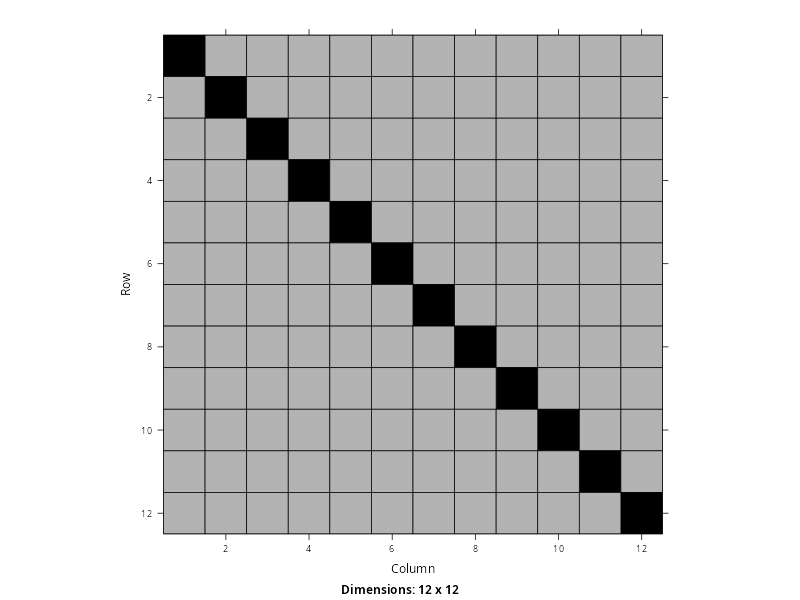

In [5]:
library('Matrix')

Sigma <- getVarCov(weightloss.lme.0, individual='1', type='marginal')$`1`
print(Sigma)
image(as(Sigma,'Matrix'))

Unsurprisingly, this is *compound symmetric*. If we believe this is too simplistic, what options do we have? 

Using a process that we will detail later, we *should* be able to fit a model per-subject that contains all random effects up to a 2-way interaction. This would have the form `random= ~ 1 + diet + exercises + time + diet:exercises + diet:time + exercises:time` or, more concisely, `random= ~ 1 + (diet + exercises + time)^2`. This echoes the error terms used in the repeated measures ANOVA and encodes the belief that each individual will vary uniquely in their response to `diet`, `exercises` and `time`, as well as the relationship between them.  

Unfortunately, the covariance structure implied by this specification is too complex to fit. This is not a problem of theory, rather it is a limitation of the software. The REML estimation procedure will keep iterating for a very long time, never converge and then stop. This will happen sometimes when using these methods. Our general rule-of-thumb is:

- < 5 seconds = normal
- 5–30 seconds = moderately complex but fine
- 30–60 seconds = suspicious
- 1–2 minutes = usually a model problem

In this case, several minutes can pass without convergence and so we are forced to simplify. In order to do so, we forget the interactions and just fit the main effects of each term as follows

In [6]:
weightloss.lme.1 <- lme(weight ~ diet*exercises*time, random= ~ 1 + diet + exercises + time|id, data=weightloss.long, control=lmeControl(opt='optim'))

This still requires us to change the optimisation algorithm using the `control=` option. The default used by `lme()` is a bit flaky and will often complain of a lack of convergence after its default number of iterations has passed. When this happens, our first method for solving this is to change the algorithm. If this still fails, we can try changing the number of iterations by setting `control=lmeControl(opt='optim', msMaxIter=200)`. If this still does not work, then it points to a more fundamental issue with the model specification.

Importantly, the implication of these random effects is that `diet`, `exercises` and `time` are allowed to vary from subject-to-subject. We assume that there is something fundamental about different individuals that changes how their weight responds to `diet`, `exercises` and `time`. However, we are forced to assume that the way these aspects interact is the *same* irrespective of the individual. So the way a person's weight responds to `diet` or `exercises` is different. Some people fundamentally respond better to `diet` over `exercises`, for instance. However, the way that these two aspects *compound* is the same across everyone. So, irrespective of how well a person responds to `diet` or `exercises`, their *combination* is always beneficial in a way that does not depend upon the specific individual. 

We will discuss more about these interpretations in the materials this week. For now, the point is to see how different random effects structures change the covariance matrix. So let us now extract the new covariance matrix and see how it compares.

            1          2          3          4           5          6           7          8          9         10         11
1  1.32509853 0.17708806 0.07621213 0.15019008 0.043238063 0.11721601 0.016340089 0.09031804 0.10307520 0.17705315 0.07617723
2  0.17708806 1.52806845 0.13098813 0.25998010 0.074706712 0.20369868 0.028606783 0.15759875 0.17701438 0.30600635 0.13091445
3  0.07621213 0.13098813 1.27867294 0.11146051 0.032184773 0.08696077 0.012657156 0.06743315 0.07618479 0.13096078 0.05665717
4  0.15019008 0.25998010 0.11146051 1.44323895 0.063653421 0.17344344 0.024923850 0.13471387 0.15012397 0.25991398 0.11139440
5  0.04323806 0.07470671 0.03218477 0.06365342 1.240963620 0.05044384 0.007921905 0.03939055 0.04321478 0.07468343 0.03216149
6  0.11721601 0.20369868 0.08696077 0.17344344 0.050443844 1.35891494 0.020188599 0.10667127 0.11715396 0.20363663 0.08689872
7  0.01634009 0.02860678 0.01265716 0.02492385 0.007921905 0.02018860 1.226227396 0.01650567 0.01632437 0.02859106 0.0

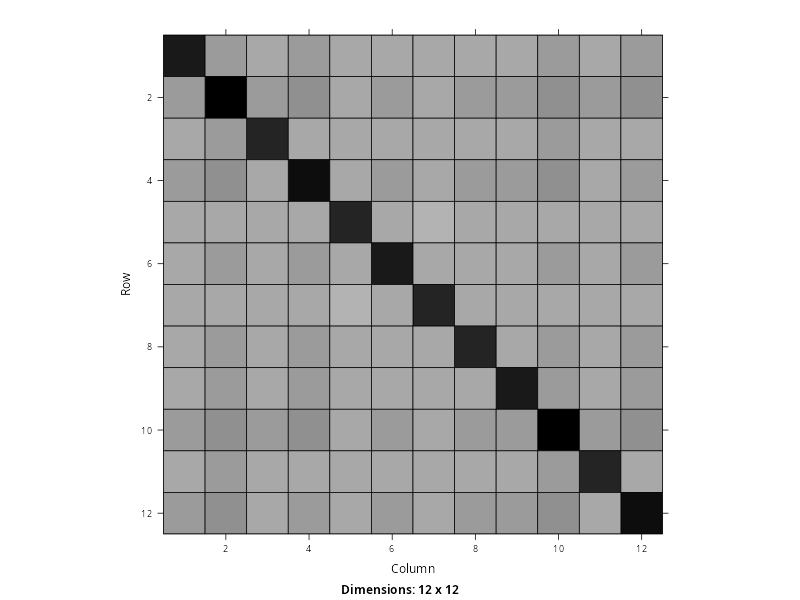

In [7]:
Sigma <- getVarCov(weightloss.lme.1, individual='1', type='marginal')$`1`
print(Sigma)
image(as(Sigma,'Matrix'))

So notice that we have now achieved the aim we had last week of a completely unstructured covariance matrix. This was too complex to fit using `gls()`, but we have managed it using a mixed-effects model.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 3</b> An alternative assumption about the random-effects structure would be that both <code>diet</code> and <code>exercises</code> affect different people in different ways, but that <code>time</code> affects everyone in the same way. How could you integrate this assumption into the model?
</div>

## Within-subject and Between-subject Factors
As well as multiple within-subject factors, we can also revisit the example from last week of the `anxiety` dataset which contains both a *within-subject* and *between-subjects* factor. We load and wrangle the data below 

In [8]:
data('anxiety')

# repeats and number of subjects
t <- 3
n <- 45

# reshape wide -> long
anxiety.long <- melt(anxiety,                 # wide data frame
                     id.vars=c('id','group'), # both id and group stay fixed
                     variable.name='time',    # name for the new predictor
                     value.name='score')      # name for the new outcome

anxiety.long           <- anxiety.long [order(anxiety.long$id),] # order by ID
rownames(anxiety.long) <- seq(1,n*t)                             # fix row names
anxiety.long$id        <- as.factor(anxiety.long$id)             # id as factor
anxiety.long$group     <- as.factor(anxiety.long$group)          # group as factor
anxiety.long$time      <- as.factor(anxiety.long$time)           # time as factor

head(anxiety.long)

  id group time score
1  1  grp1   t1  14.1
2  1  grp1   t2  14.4
3  1  grp1   t3  14.1
4  2  grp1   t1  14.5
5  2  grp1   t2  14.6
6  2  grp1   t3  14.3

As we can see, this is much simpler than the `weightloss` dataset. But with this simplicity comes *fewer options*.

### Random-effect Specification
Unlike the previous example, there are no replications within the repeated measurements. Each subject only has a single `score` at each time-point. Our heuristic is that we can therefore only use a *random intercept* model. Again, the logic of this will be more explicitly laid out in the materials this week.

We can fit the model using the syntax below with `random= ~ 1|id` used for the random effects

In [9]:
anxiety.lme.0 <- lme(score ~ group*time, random= ~ 1|id, data=anxiety.long)
summary(anxiety.lme.0)

Linear mixed-effects model fit by REML
  Data: anxiety.long 
       AIC     BIC    logLik
  278.6349 309.834 -128.3174

Random effects:
 Formula: ~1 | id
        (Intercept)  Residual
StdDev:     1.53169 0.2903382

Fixed effects:  score ~ group * time 
                     Value Std.Error DF   t-value p-value
(Intercept)      17.086667 0.4025229 84  42.44893  0.0000
groupgrp2        -0.440000 0.5692534 42  -0.77294  0.4439
groupgrp3        -0.073333 0.5692534 42  -0.12882  0.8981
timet2           -0.160000 0.1060165 84  -1.50920  0.1350
timet3           -0.580000 0.1060165 84  -5.47084  0.0000
groupgrp2:timet2 -0.020000 0.1499300 84  -0.13340  0.8942
groupgrp3:timet2 -1.840000 0.1499300 84 -12.27239  0.0000
groupgrp2:timet3 -0.540000 0.1499300 84  -3.60168  0.0005
groupgrp3:timet3 -2.873333 0.1499300 84 -19.16450  0.0000
 Correlation: 
                 (Intr) grpgr2 grpgr3 timet2 timet3 grp2:2 grp3:2 grp2:3
groupgrp2        -0.707                                                 
groupg

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 4</b> Can you confirm the covariance structure for this model by extracting and visualising it?
</div>

We can continue with our usual approach of generating omnibus tests

In [10]:
Anova(anxiety.lme.0)

Analysis of Deviance Table (Type II tests)

Response: score
              Chisq Df Pr(>Chisq)    
group        8.7036  2    0.01288 *  
time       789.8190  2    < 2e-16 ***
group:time 440.7504  4    < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

and can plot the `group:time` effect

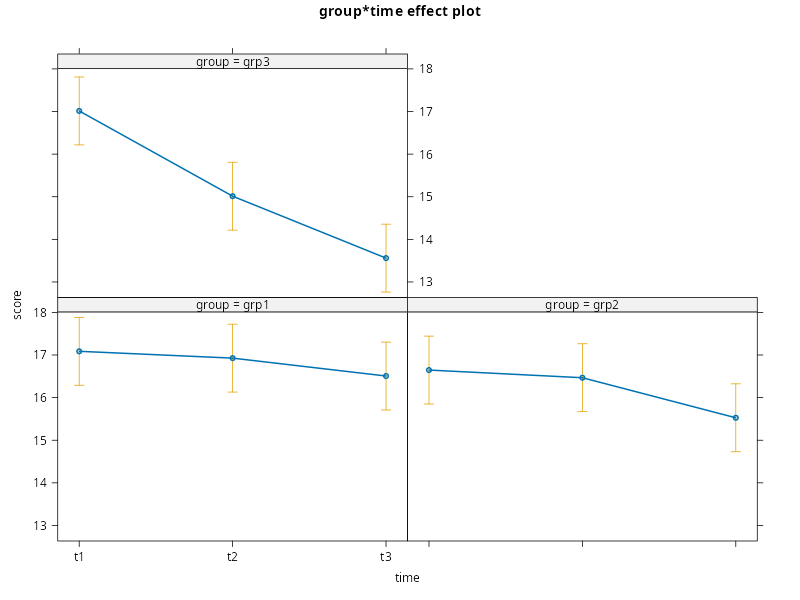

In [11]:
plot(effect('group:time', anxiety.lme.0), x.var='time')

where there appears to be a clear change in the effect of `time` depending upon the `group`.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 5</b> Can you follow-up this interaction using <code>emmeans</code>? Remember to check that your inferential approach is <i>consistent</i> with the method used by <code>Anova()</code>.
</div>

### Multilevel Conceptualisation
As we saw earlier, we can present the multilevel version of this model. Again, the process of building this will be given in much more detail in the materials this week, so do not worry about understanding every aspect of this. The aim is that, by the end of next week, you would be able to build the model below from first principles and will understand where its various elements have come from.

$$
\begin{alignat*}{1}
\text{Level 1}\\
    y_{ijk} &= \mu_{i} + \alpha_{j} + (\alpha\beta)_{jk} + \eta_{ijk} \\
    \quad \\
\text{Level 2} \\
    \mu_{i} &= \mu + \beta_{k} + \xi_{i}
\end{alignat*}
$$

For now, notice that the *between-subjects* factor enters at Level 2. This again echoes how this effects are split into error terms in the repeated measures ANOVA. In these very basic models we can think of Level 1 in relation to the *within-subject* elements of the data and Level 2 in relation to the *between-subjects* elements of the data.

### Including a `weights=` Structure
As mentioned, the lack of replications limits the random-effects structure. If we were using the `lme4` package, we would have no further options and would be forced to accept compound symmetry. However, an advantage of `lme()` is that we have access to same `weights=` options as `gls()`. This means that we can make the structure more general across the levels of `group` by allowing different variances. The syntax for this is

In [12]:
anxiety.lme.1 <- lme(score ~ group*time, random= ~ 1|id, weights=varIdent(form= ~ 1|group), data=anxiety.long)
summary(anxiety.lme.1)

Linear mixed-effects model fit by REML
  Data: anxiety.long 
       AIC      BIC    logLik
  281.9984 318.8701 -127.9992

Random effects:
 Formula: ~1 | id
        (Intercept)  Residual
StdDev:     1.53192 0.3013514

Variance function:
 Structure: Different standard deviations per stratum
 Formula: ~1 | group 
 Parameter estimates:
     grp1      grp2      grp3 
1.0000000 0.8785575 1.0062156 
Fixed effects:  score ~ group * time 
                     Value Std.Error DF   t-value p-value
(Intercept)      17.086667 0.4031204 84  42.38602  0.0000
groupgrp2        -0.440000 0.5688857 42  -0.77344  0.4436
groupgrp3        -0.073333 0.5701645 42  -0.12862  0.8983
timet2           -0.160000 0.1100380 84  -1.45404  0.1497
timet3           -0.580000 0.1100380 84  -5.27091  0.0000
groupgrp2:timet2 -0.020000 0.1464731 84  -0.13654  0.8917
groupgrp3:timet2 -1.840000 0.1561016 84 -11.78720  0.0000
groupgrp2:timet3 -0.540000 0.1464731 84  -3.68668  0.0004
groupgrp3:timet3 -2.873333 0.1561016 84 -18.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 6</b> Use the data to identify the <code>id</code> of the first subject from each level of <code>group</code>. Extract the covariance matrices for each of these subjects and compare them.
</div>

### Model Comparisons
We can also use model comparisons to determine whether these types of choice are supported by the data. For instance, to see if the `weights=` structure is needed, we can use

In [13]:
mod.0 <- lme(score ~ group*time, random= ~ 1|id,                                    data=anxiety.long, method='ML')
mod.1 <- lme(score ~ group*time, random= ~ 1|id, weights=varIdent(form= ~ 1|group), data=anxiety.long, method='ML')

anova(mod.0,mod.1)

      Model df      AIC      BIC    logLik   Test   L.Ratio p-value
mod.0     1 11 261.5386 293.4966 -119.7693                         
mod.1     2 13 264.8566 302.6252 -119.4283 1 vs 2 0.6819275  0.7111

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 7</b> Does this result suggest that a different variance per-level of <code>group</code> is needed or not? How does the assumption of homogeneity of variance affect the inference?
</div>

## Model Assumptions
Assessing the assumptions of a mixed-effects model is very similar in spirit to what we have seen previously, particularly given the discussion of GLS in the last workshop. Below, we present a function similar to the `plot.gls()` function we created last week. The key differences are

- An explicit `vcov.id` is needed to extract the marginal covariance matrix for a single individual
- The normality of the random effects needs to be checked and so additional QQ-normal plots are added dynamically, depending upon the number of random effects in the model.

In [14]:
plot.lme <- function(mod, vcov.id){

  resid.norm <- resid(mod, type="normalized")
  fit        <- fitted(mod)

  rand.effs  <- random.effects(mod)
  rand.names <- colnames(rand.effs)
  n.rand     <- dim(rand.effs)[2]

  n.rows <- 2 + ceiling(n.rand/2)
  par(mfrow=c(n.rows,2))

  # Residuals vs fitted
  plot(fit, resid.norm, main='Residuals vs fitted')
  lines(lowess(fit,resid.norm))

  # Normal Q-Q
  qqnorm(resid.norm, main="Residuals") 
  qqline(resid.norm)
  
  # Scale-Location
  plot(fit, sqrt(abs(resid.norm)), main='Scale-Location')
  lines(lowess(fit,sqrt(abs(resid.norm))))

  # Visualisation of the marginal covariance structure
  V <- getVarCov(mod, type='marginal', individual=vcov.id)[[vcov.id]]
  graphics::image(as.matrix(V)[nrow(V):1, ], main=paste0('Marginal covariance structure (ID=', vcov.id, ')'))

  ## Normal Q-Q of the random effects
  for (i in 1:n.rand){
    RE <- rand.effs[,i]
    qqnorm(RE, main=rand.names[i]) 
    qqline(RE)
  }
}

We can use this function with the last model of `anxiety` that we fit

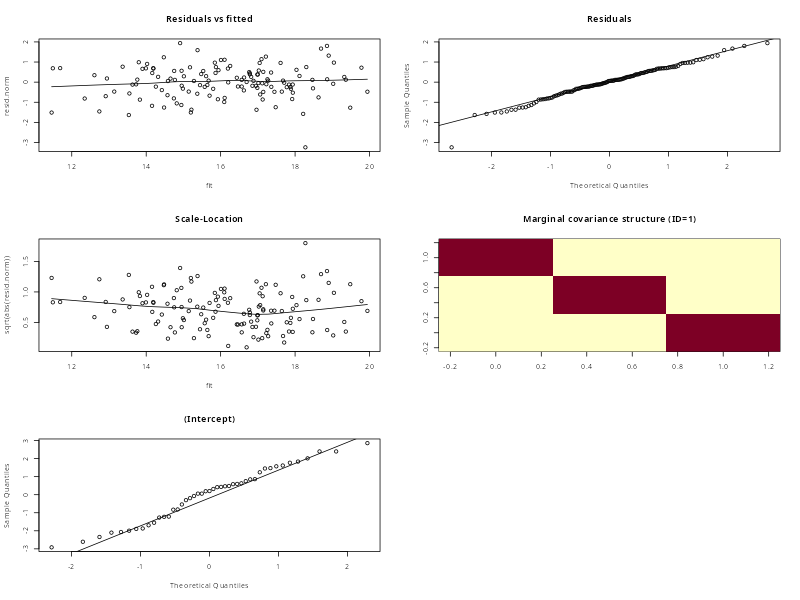

In [15]:
plot.lme(anxiety.lme.1, vcov.id='1')

Of note is that the *normalised* residuals are used because they have had the covariance structure *removed*. If we have captured the correlational and variance differences correctly, there should be no structure left here. In addition, we have the normality of the random effects to consider. 

In general, the normality assumption for random effects is there to make estimation possible. Minor deviations are not really that important. If the distribution looks very non-normal, the first suspicion should be that the model is missing structure (e.g. additional groups that are not captured by the current random effects). Another possibility is that some of the individuals in the model have unusual data. So, any non-normality here points towards either model misspecification or some particularly odd cases. Beyond dealing with these possibilities, there is not much we can do if normality appears poorly met.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY 8</b> Try using this function to generate plots from some other models in this lesson, particularly those with multiple random effects, and try changing the option for <code>vcov.id</code>.
</div>